## Settings 

In [1]:
import os 
from pathlib import Path 
# "code_search", "circuit_eval", "etl_pipeline", "meshctl", "mocked_http", "recli", "sheeteval", "sith"
PROBLEMS = [
    "code_search", "circuit_eval", "etl_pipeline", "meshctl", "mocked_http", "recli", "sheeteval", "sith"
    ]
AGENT = "codex"
MODELS = ["gpt-5.6-luna", "gpt-5.4-mini"]
MODES = ["noDesign","auto", "autoNoMetric"]   

# List all the directories found 
# if TYPE == "custom": 
#     dirs = [
#         Path(f"datasets/custom/problems/{PROBLEM}/implementations_{x}_{AGENT}_{MODEL}") for x in MODES
#     ]
# elif TYPE == "scb": 
#     dirs = [
#         Path(f"datasets/slopCodeBench/scb-problems/{PROBLEM}/implementations_{x}_{AGENT}_{MODEL}") for x in MODES
#     ]
# else: 
#     raise Exception(f"Invalid problem type: {TYPE}")

# # Verify if the paths exist (also verifies if the problem is valid) 
# for path in dirs: 
#     if not path.exists(): 
#         raise Exception(f"Path does not exist: {path}")
# dirs


## Helper function to filter certain problems only

In [2]:
def filter_problems(metrics): 
    return {k:v for k, v in metrics.items() if k in PROBLEMS}

## Read from cached evaluation metrics

In [3]:
import json 

# References metrics are the github metrics 
with open("metrics_cache/references_metrics.json", 'r') as f: 
    references_metrics = json.load(f)

# scb metrics are the agent implemented scb dataset problems metrics 
with open("metrics_cache/scb_metrics.json", 'r') as f: 
    scb_metrics = filter_problems(json.load(f))

with open("metrics_cache/scb_report_metrics.json", 'r') as f: 
    scb_report_metrics = filter_problems(json.load(f))

with open("metrics_cache/scb_test_metrics.json", 'r') as f: 
    scb_test_metrics = filter_problems(json.load(f))

## Average helper function

In [4]:
# Given a list of [{key1: .., key2: ...}, {...}]
# Aggregate and find the average of each key 
def average(data): 
    return {
        key: sum(d[key] for d in data) / len(data) for key in data[0]
    }


## Interpolate and aggregate scb metrics

In [5]:
from reusables.interpolation import linear_interpolation_metrics 

# Interpolate the checkpoint metrics to 8 
# Aggregate the interpolated checkpoint metrics by problem
def interpolate_and_aggregate(metrics_json): 
    metrics_interpolated = {
        problem: {
            s: linear_interpolation_metrics(values, 8)
            for s, values in data.items()
        }
        for problem, data in metrics_json.items()
    }

    metrics_aggregated = {}

    # Collect each implementation key across problems
    implementation_keys = {
        key
        for data in metrics_interpolated.values()
        for key in data
    }

    for key in sorted(implementation_keys):
        problem_series = [
            data[key]
            for data in metrics_interpolated.values()
            if key in data
        ]

        # Average the corresponding interpolated checkpoints 1-8 across problems 
        metrics_aggregated[key] = [
            average([series[checkpoint] for series in problem_series])
            for checkpoint in range(8)  # 8 is the interpolated number of checkpoints 
        ]

    return metrics_aggregated

scb_metrics_aggregated = interpolate_and_aggregate(scb_metrics)
report_metrics_aggregated = interpolate_and_aggregate(scb_report_metrics)
test_metrics_aggregated = interpolate_and_aggregate(scb_test_metrics)
report_metrics_aggregated

{'report_autoByLayer_codex_gpt-5.6-luna': [{'total': 241460.66666666666,
   'non_cached': 33759.333333333336},
  {'total': 350939.0, 'non_cached': 39472.333333333336},
  {'total': 477290.6666666667, 'non_cached': 48746.666666666664},
  {'total': 408727.0, 'non_cached': 39489.666666666664},
  {'total': 401462.3333333333, 'non_cached': 48182.333333333336},
  {'total': 621284.3333333334, 'non_cached': 58596.333333333336},
  {'total': 622715.3333333334, 'non_cached': 57638.0},
  {'total': 616976.6666666666, 'non_cached': 64699.333333333336}],
 'report_autoNoMetric_codex_gpt-5.4-mini': [{'total': 376220.5,
   'non_cached': 33100.5},
  {'total': 305133.1785714286, 'non_cached': 33325.17857142857},
  {'total': 420808.3214285714, 'non_cached': 38520.32142857143},
  {'total': 577108.0357142857, 'non_cached': 42145.75},
  {'total': 498661.9642857143, 'non_cached': 40291.67857142857},
  {'total': 341064.5357142857, 'non_cached': 25453.107142857145},
  {'total': 350485.875, 'non_cached': 28012.732

## Interpolate the reference metrics 

In [6]:
from reusables.interpolation import linear_interpolation_metrics

references_metrics_interpolated = {
    problem: linear_interpolation_metrics(arr, 8) for problem, arr in references_metrics.items() 
}

references_metrics_interpolated

{'fastapi': [{'lloc': 1750.0,
   'loc': 4134.0,
   'lloc_per_function': 14.831,
   'lloc_per_module': 70.0,
   'function_max_loc': 99.0,
   'modules_max_lloc': 425.0,
   'comments_percentage': 1.258,
   'cc_per_function': 3.458,
   'high_cc_functions_count': 8.0,
   'function_max_cc': 22.0,
   'weighted_mi': 40.25,
   'propagation_cost': 0.29,
   'impact_size': 6.24,
   'average_degree': 3.36,
   'number_of_modules': 25.0,
   'number_of_functions': 118.0,
   'number_of_functions_per_module': 4.72,
   'nopm_per_class': 0.726,
   'class_max_nopm': 16.0,
   'duplicated_lines': 0.311,
   'duplicated_tokens': 0.31},
  {'lloc': 2065.4285714285716,
   'loc': 4765.714285714285,
   'lloc_per_function': 15.370142857142858,
   'lloc_per_module': 77.23771428571429,
   'function_max_loc': 116.14285714285714,
   'modules_max_lloc': 431.85714285714283,
   'comments_percentage': 2.4142857142857146,
   'cc_per_function': 3.8351428571428574,
   'high_cc_functions_count': 8.0,
   'function_max_cc': 24.57

## Average out the references metrics 

In [7]:
references_metrics_averaged = [] 
for i in range(8): 
    # extract the checkpoint i data 
    checkpoint_data = [v[i] for k, v in references_metrics_interpolated.items()]
    references_metrics_averaged.append(average(checkpoint_data))

references_metrics_averaged

[{'lloc': 1565.0,
  'loc': 3358.875,
  'lloc_per_function': 12.160625,
  'lloc_per_module': 107.841,
  'function_max_loc': 79.125,
  'modules_max_lloc': 417.25,
  'comments_percentage': 6.68225,
  'cc_per_function': 2.806,
  'high_cc_functions_count': 5.375,
  'function_max_cc': 17.5,
  'weighted_mi': 45.611000000000004,
  'propagation_cost': 0.43425,
  'impact_size': 5.023125,
  'average_degree': 2.814375,
  'number_of_modules': 13.5,
  'number_of_functions': 140.875,
  'number_of_functions_per_module': 9.61275,
  'nopm_per_class': 2.6185,
  'class_max_nopm': 22.375,
  'duplicated_lines': 0.047,
  'duplicated_tokens': 0.05},
 {'lloc': 1892.1785714285713,
  'loc': 3949.857142857143,
  'lloc_per_function': 12.452339285714286,
  'lloc_per_module': 114.77105357142857,
  'function_max_loc': 87.58928571428571,
  'modules_max_lloc': 471.30357142857144,
  'comments_percentage': 6.192303571428572,
  'cc_per_function': 2.9714642857142857,
  'high_cc_functions_count': 6.178571428571429,
  'funct

## Reusable plot function

Takes in format: 
```py
{
    "string": [{}, {}, ...] (length of 8) 
}
```

In [8]:
from matplotlib import pyplot as plt 
import math 
import matplotlib as mpl
import numpy as np
from matplotlib.ticker import MaxNLocator

# A mapping for the labels displayed 
displayed_labels = {
    "noDesign": "Direct Coding", 
    "auto": "Multi-Agent", 
    "autoNoMetric": "Multi-Agent with Metrics Removed", 
    "autoTest": "Multi-Agent with TDD"
}
# Metrics must be in the form of { mode1: [{}, {}, ...], mode2: ... }<- one array for one mode]
# Metrics names must be in the form of array stating which metric to plot 
# With references = whether or not to show github repo analysis of the same metrics, side by side 
# y labels must be same size as metrics_names 
def plot(metrics_json, metrics_names, with_references = False, y_labels = None): 
    
        if y_labels and len(y_labels) != len(metrics_names): 
            raise Exception("Y labels length does not equal metric names length") 
        
        N = len(metrics_names) 
        ROWS = math.ceil(N/2) if N > 2 else 1 
        COLS = 2 if N >= 2 else 1

        # special case hard code rows = 1 cols = 3 if N == 3 
        if N == 3: 
            ROWS = 1 
            COLS = 3 
            
        figsize = (5*COLS, 5*ROWS)
        fig, axes = plt.subplots(ROWS, COLS, figsize=figsize)
        if N > 3: 
            axes = np.atleast_1d(axes).flatten()

        if N == 1: 
            axes = [axes] # weird matplotlib feature 

        # Use different colors for metrics and ref
        metric_colors = mpl.colormaps["tab10"].resampled(max(len(MODELS) * len(MODES), 1))
        ref_colors = mpl.colormaps["Greys"].resampled(max(len(references_metrics), 1) + 2) if with_references else None

        for i, metric in enumerate(metrics_names): 
            ax = axes[i]

            for model_index, model in enumerate(MODELS):
                l = 0 
                for (j, mode) in enumerate(MODES):
                    # Obtain the data from the given metrics 
                    suffix = f"_{mode}_{AGENT}_{model}"
                    impl_key = None 
                    for key, value in metrics_json.items(): 
                        if key.endswith(suffix): 
                            impl_key = key 
                            break 

                    data = [x[metric] for x in metrics_json[impl_key]]
                    l = max(l, len(data))
                    
                    x = range(1, len(data) + 1) 
                    y = data

                    print(f"{mode}, {metric}, {model}: {[round(x,3) for x in data]}")

                    # x axis integer only 
                    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
                    ax.plot(x, y, label=f"{displayed_labels.get(MODES[j], "unknown")}-{model}", color=metric_colors(model_index * len(MODES) + j),linestyle="-",)

            if with_references: 
                for k, (key, value) in enumerate(references_metrics_interpolated.items()):
                    # SKIP if metric = duplicated lines or duplicated tokens and problem = fastapi: 
                    # Remove outlier 
                    if metric in ["duplicated_lines", "duplicated_tokens"] and key == "fastapi": 
                        continue 
                    
                    # Obtain the list of metric from the value 
                    reference_metric_list = [x.get(metric, 0) for x in value]

                    # Plot on the same graph 
                    x = range(1, len(reference_metric_list) + 1) 
                    y = reference_metric_list

                    # Display references label only for the last entry 
                    if k == len(references_metrics_interpolated)-1: 
                        ax.plot(x, y, label=f"Referenced GitHub Repos", color=ref_colors(k + 1), linestyle="--",)  # label=f"Ref: {key}"
                    else: 
                        ax.plot(x, y, color=ref_colors(k + 1), linestyle="--",)  # label=f"Ref: {key}"
                        
                # print the average 
                print(f"references-average, {metric}: {[round(x,2) for x in [y[metric] for y in references_metrics_averaged]]}")

            ylabel = metric if not y_labels else y_labels[i]
            ax.set_xlabel("Checkpoint Number (Interpolated)")
            ax.set_ylabel(ylabel)
            ax.set_title(f"{ylabel} against Checkpoints")
            ax.legend()

        plt.tight_layout()
        plt.show()

## Token counts in the impl stage

noDesign, total, gpt-5.6-luna: [304132.25, 445089.929, 517433.161, 531034.054, 577154.804, 752806.232, 806666.321, 1006769.5]
auto, total, gpt-5.6-luna: [416790.75, 622075.107, 819699.5, 880533.196, 1043847.964, 1009490.5, 1355192.768, 1542491.875]
autoNoMetric, total, gpt-5.6-luna: [479653.625, 593586.125, 896861.107, 1004896.107, 1034919.411, 1457998.089, 1338019.929, 1527076.0]
noDesign, total, gpt-5.4-mini: [488029.75, 419207.857, 766228.518, 1048345.875, 1010935.321, 1331915.804, 1474648.554, 2010648.875]
auto, total, gpt-5.4-mini: [596870.25, 735530.464, 866487.607, 1014256.714, 865078.393, 860856.679, 540109.875, 498824.75]
autoNoMetric, total, gpt-5.4-mini: [376220.5, 305133.179, 420808.321, 577108.036, 498661.964, 341064.536, 350485.875, 375501.5]
noDesign, non_cached, gpt-5.6-luna: [40084.25, 43334.5, 50541.732, 48976.911, 51787.946, 63681.661, 53507.464, 64161.5]
auto, non_cached, gpt-5.6-luna: [41366.75, 56968.821, 64910.929, 73440.625, 69091.393, 76231.071, 82397.339, 8666

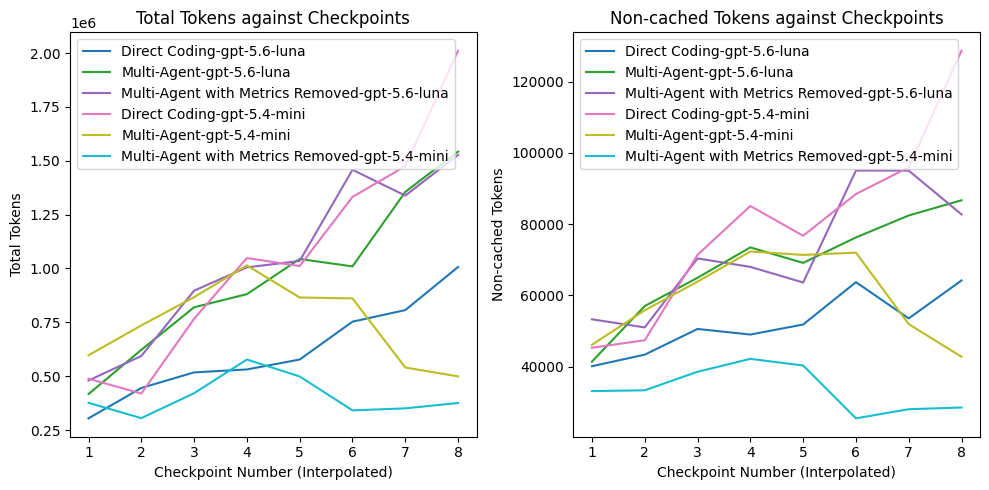

In [9]:
plot(report_metrics_aggregated, ["total", "non_cached"], y_labels=["Total Tokens", "Non-cached Tokens"])

## LOC

noDesign, lloc, gpt-5.6-luna: [230.0, 350.0, 469.625, 559.089, 702.214, 833.125, 987.5, 1168.25]
auto, lloc, gpt-5.6-luna: [329.375, 503.321, 663.464, 799.893, 984.161, 1190.482, 1466.0, 1724.125]
autoNoMetric, lloc, gpt-5.6-luna: [361.0, 535.982, 737.071, 892.321, 1116.857, 1375.107, 1641.536, 1918.75]
noDesign, lloc, gpt-5.4-mini: [311.5, 447.018, 666.643, 738.571, 998.786, 1237.25, 1387.393, 1537.5]
auto, lloc, gpt-5.4-mini: [382.25, 547.625, 694.125, 799.232, 915.107, 1019.946, 1029.75, 1107.625]
autoNoMetric, lloc, gpt-5.4-mini: [257.375, 322.821, 462.446, 521.286, 615.482, 642.321, 638.804, 655.875]
noDesign, lloc_per_function, gpt-5.6-luna: [21.091, 20.598, 20.53, 21.753, 21.98, 22.875, 23.397, 23.958]
auto, lloc_per_function, gpt-5.6-luna: [13.526, 13.009, 12.614, 12.673, 11.901, 11.555, 12.01, 12.137]
autoNoMetric, lloc_per_function, gpt-5.6-luna: [15.7, 15.143, 13.916, 13.639, 12.942, 12.615, 12.848, 13.043]
noDesign, lloc_per_function, gpt-5.4-mini: [14.477, 15.52, 15.965, 1

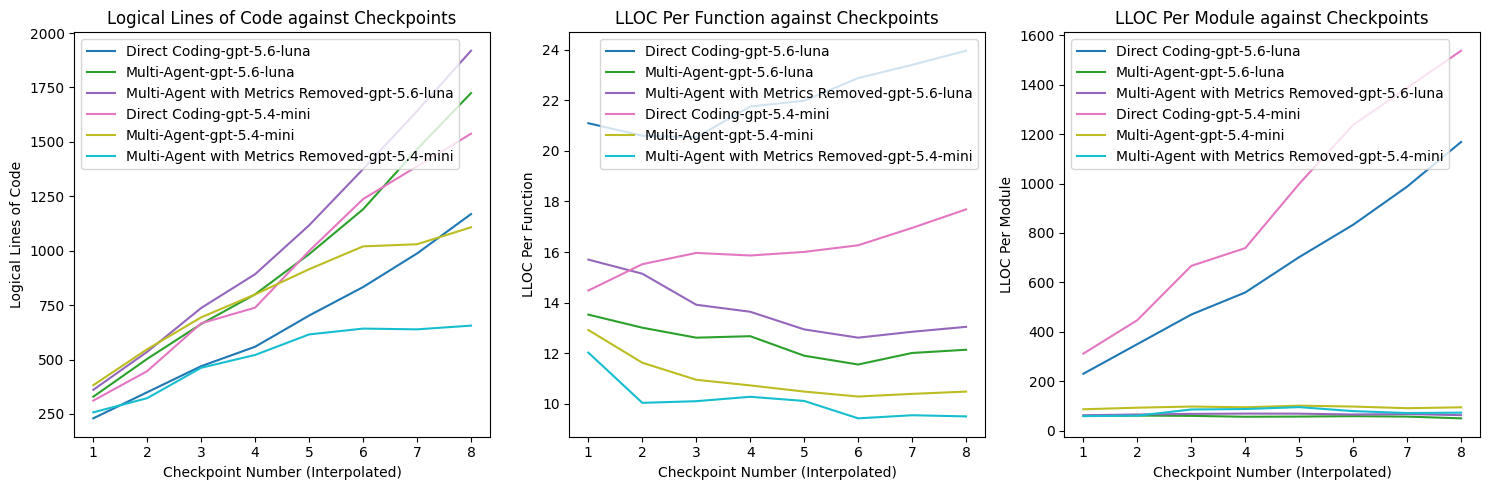

In [10]:
plot(scb_metrics_aggregated, ["lloc", "lloc_per_function", "lloc_per_module"], with_references=False, y_labels=["Logical Lines of Code", "LLOC Per Function", "LLOC Per Module"])

## High CC functions and High LOC functions

noDesign, high_cc_functions_count, gpt-5.6-luna: [1.75, 2.393, 2.929, 3.643, 4.839, 5.661, 6.857, 8.0]
auto, high_cc_functions_count, gpt-5.6-luna: [0.125, 0.411, 0.536, 1.589, 1.125, 0.661, 0.768, 1.125]
autoNoMetric, high_cc_functions_count, gpt-5.6-luna: [1.25, 2.5, 3.107, 3.839, 4.464, 5.411, 6.214, 6.75]
noDesign, high_cc_functions_count, gpt-5.4-mini: [1.875, 2.714, 3.875, 4.875, 6.286, 7.0, 8.161, 9.75]
auto, high_cc_functions_count, gpt-5.4-mini: [0.375, 0.589, 0.75, 0.607, 0.339, 0.643, 0.554, 1.0]
autoNoMetric, high_cc_functions_count, gpt-5.4-mini: [0.5, 0.625, 0.661, 1.054, 1.696, 1.321, 1.429, 1.25]
noDesign, function_max_cc, gpt-5.6-luna: [23.5, 27.25, 31.964, 34.75, 39.125, 48.607, 60.464, 70.125]
auto, function_max_cc, gpt-5.6-luna: [8.625, 10.339, 10.625, 13.732, 12.875, 11.054, 12.143, 13.75]
autoNoMetric, function_max_cc, gpt-5.6-luna: [16.875, 20.804, 20.232, 19.768, 20.089, 19.393, 21.839, 25.125]
noDesign, function_max_cc, gpt-5.4-mini: [18.875, 21.75, 23.857, 24.

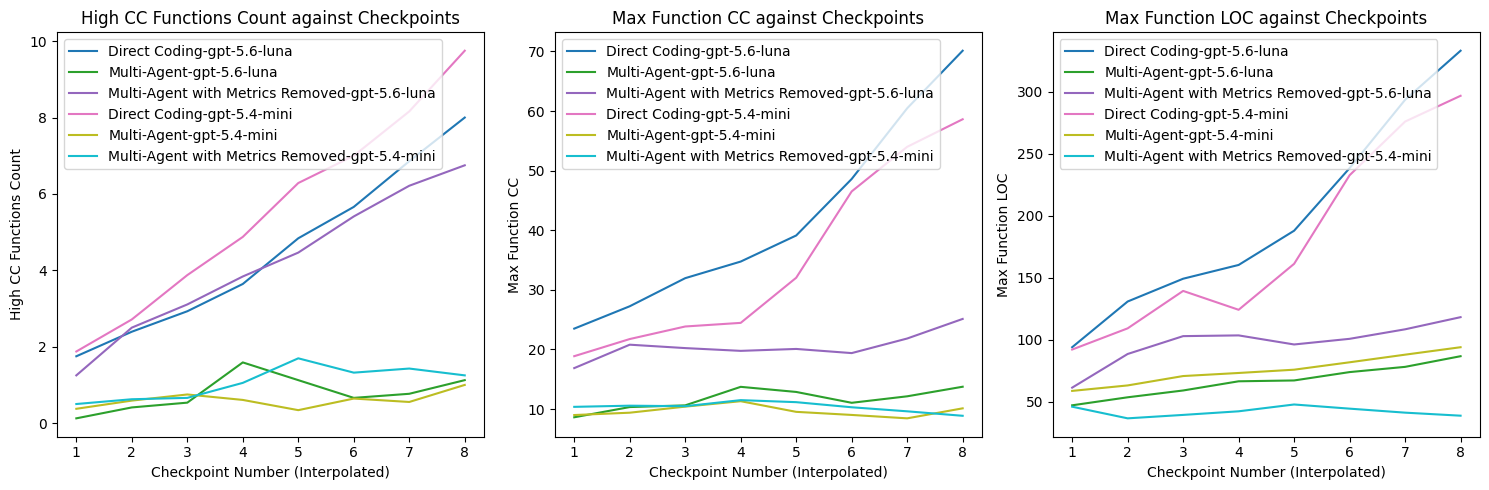

In [11]:
plot(scb_metrics_aggregated, ["high_cc_functions_count", "function_max_cc", "function_max_loc"], with_references=False, y_labels=["High CC Functions Count", "Max Function CC","Max Function LOC"])

## Weighted MI

noDesign, weighted_mi, gpt-5.6-luna: [22.206, 11.196, 5.192, 3.103, 1.741, 0.348, 0.0, 0.0]
auto, weighted_mi, gpt-5.6-luna: [42.977, 40.894, 39.364, 40.093, 39.416, 39.049, 40.16, 42.694]
autoNoMetric, weighted_mi, gpt-5.6-luna: [42.306, 40.459, 38.668, 36.986, 37.719, 38.59, 37.872, 38.634]
noDesign, weighted_mi, gpt-5.4-mini: [19.598, 10.054, 5.064, 7.519, 3.221, 1.155, 1.828, 1.103]
auto, weighted_mi, gpt-5.4-mini: [37.757, 37.013, 34.013, 29.776, 28.339, 30.037, 33.73, 31.563]
autoNoMetric, weighted_mi, gpt-5.4-mini: [41.785, 39.693, 33.851, 33.271, 31.476, 36.191, 41.062, 40.178]


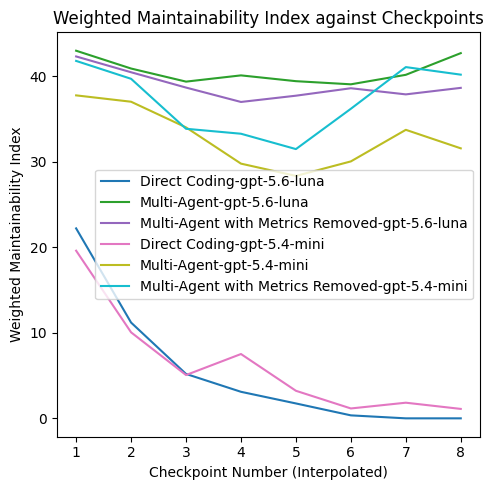

In [12]:
plot(scb_metrics_aggregated, ["weighted_mi"], with_references=False, y_labels=["Weighted Maintainability Index"])

## Duplicated lines and tokens

noDesign, duplicated_lines, gpt-5.6-luna: [0.0, 0.0, 0.001, 0.004, 0.007, 0.008, 0.007, 0.009]
auto, duplicated_lines, gpt-5.6-luna: [0.0, 0.001, 0.001, 0.0, 0.0, 0.001, 0.001, 0.001]
autoNoMetric, duplicated_lines, gpt-5.6-luna: [0.0, 0.0, 0.003, 0.002, 0.002, 0.003, 0.003, 0.005]
noDesign, duplicated_lines, gpt-5.4-mini: [0.0, 0.003, 0.009, 0.008, 0.019, 0.031, 0.036, 0.041]
auto, duplicated_lines, gpt-5.4-mini: [0.0, 0.001, 0.003, 0.008, 0.008, 0.005, 0.004, 0.007]
autoNoMetric, duplicated_lines, gpt-5.4-mini: [0.003, 0.002, 0.015, 0.038, 0.01, 0.008, 0.007, 0.007]


references-average, duplicated_lines: [0.05, 0.06, 0.05, 0.05, 0.06, 0.09, 0.08, 0.08]
noDesign, duplicated_tokens, gpt-5.6-luna: [0.0, 0.0, 0.002, 0.005, 0.008, 0.008, 0.007, 0.009]
auto, duplicated_tokens, gpt-5.6-luna: [0.0, 0.001, 0.001, 0.0, 0.0, 0.001, 0.001, 0.001]
autoNoMetric, duplicated_tokens, gpt-5.6-luna: [0.0, 0.0, 0.005, 0.003, 0.002, 0.003, 0.004, 0.006]
noDesign, duplicated_tokens, gpt-5.4-mini: [0.0, 0.003, 0.011, 0.009, 0.02, 0.031, 0.036, 0.044]
auto, duplicated_tokens, gpt-5.4-mini: [0.0, 0.001, 0.004, 0.01, 0.011, 0.007, 0.006, 0.009]
autoNoMetric, duplicated_tokens, gpt-5.4-mini: [0.004, 0.002, 0.016, 0.041, 0.011, 0.009, 0.01, 0.011]
references-average, duplicated_tokens: [0.05, 0.07, 0.06, 0.06, 0.07, 0.09, 0.09, 0.09]


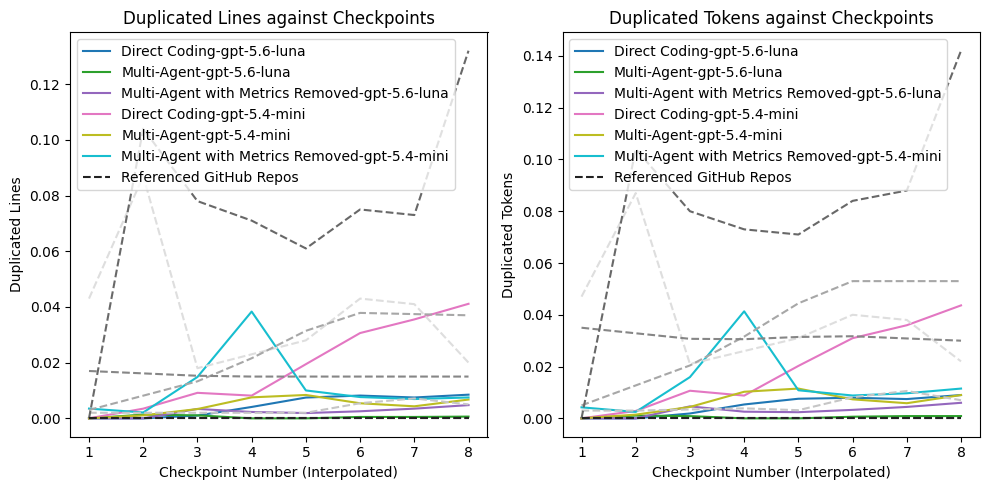

In [13]:
plot(scb_metrics_aggregated, ["duplicated_lines", "duplicated_tokens"], with_references=True, y_labels=["Duplicated Lines", "Duplicated Tokens"])

## Graph average degree

noDesign, average_degree, gpt-5.6-luna: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
auto, average_degree, gpt-5.6-luna: [1.825, 2.091, 2.234, 2.428, 2.517, 2.536, 2.67, 2.751]
autoNoMetric, average_degree, gpt-5.6-luna: [2.034, 2.294, 2.559, 2.692, 2.914, 2.958, 3.026, 3.097]
noDesign, average_degree, gpt-5.4-mini: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
auto, average_degree, gpt-5.4-mini: [1.753, 1.923, 1.986, 1.988, 2.02, 2.112, 2.239, 2.256]
autoNoMetric, average_degree, gpt-5.4-mini: [1.523, 1.651, 1.739, 1.873, 1.979, 2.091, 2.123, 2.08]
references-average, average_degree: [2.81, 2.84, 2.91, 2.93, 3.0, 3.11, 3.23, 3.36]


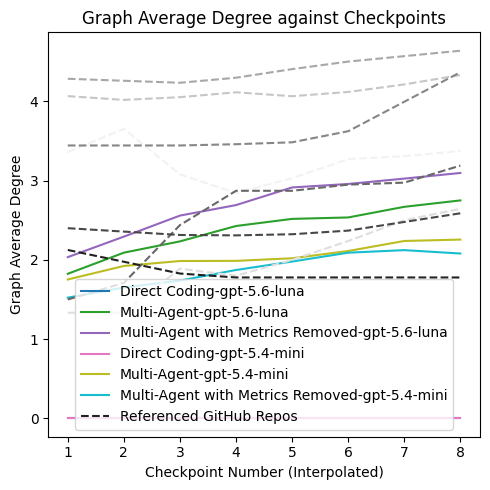

In [14]:
plot(scb_metrics_aggregated, ["average_degree"], with_references=True, y_labels=["Graph Average Degree"])

## Number of public methods per module

noDesign, nopm_per_class, gpt-5.6-luna: [3.708, 5.141, 5.855, 6.155, 7.85, 9.263, 9.362, 10.562]
auto, nopm_per_class, gpt-5.6-luna: [0.726, 0.772, 0.881, 0.961, 1.01, 1.04, 0.989, 1.049]
autoNoMetric, nopm_per_class, gpt-5.6-luna: [0.676, 0.723, 0.816, 0.808, 0.856, 0.912, 0.899, 0.893]
noDesign, nopm_per_class, gpt-5.4-mini: [7.872, 8.942, 9.12, 6.238, 9.186, 11.345, 10.505, 11.47]
auto, nopm_per_class, gpt-5.4-mini: [0.974, 1.065, 1.089, 1.182, 1.545, 1.322, 1.278, 1.272]
autoNoMetric, nopm_per_class, gpt-5.4-mini: [0.63, 0.662, 0.749, 0.816, 0.846, 0.904, 0.931, 0.913]
references-average, nopm_per_class: [2.62, 2.63, 2.52, 2.41, 2.42, 2.41, 2.28, 2.33]
noDesign, class_max_nopm, gpt-5.6-luna: [6.5, 8.804, 11.125, 13.161, 16.732, 21.536, 25.804, 29.125]
auto, class_max_nopm, gpt-5.6-luna: [2.0, 3.607, 5.643, 6.589, 6.75, 7.214, 8.286, 9.0]
autoNoMetric, class_max_nopm, gpt-5.6-luna: [3.125, 3.857, 5.107, 5.554, 6.821, 7.214, 8.321, 8.75]
noDesign, class_max_nopm, gpt-5.4-mini: [17.25

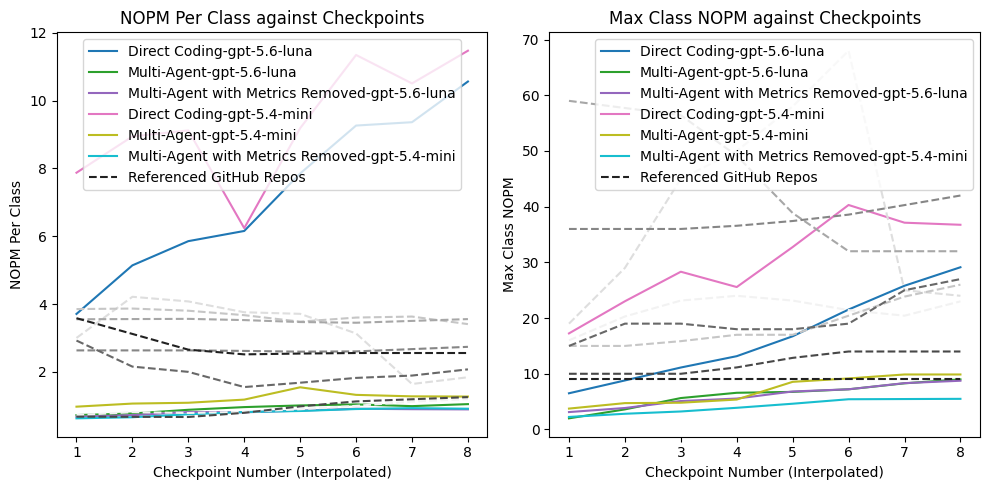

In [15]:
plot(scb_metrics_aggregated, ["nopm_per_class", "class_max_nopm"], with_references=True, y_labels=["NOPM Per Class", "Max Class NOPM"])

## Number of functions (per module)

noDesign, number_of_functions, gpt-5.6-luna: [11.375, 17.946, 23.929, 27.411, 34.375, 41.286, 48.857, 56.5]
auto, number_of_functions, gpt-5.6-luna: [25.375, 40.357, 55.339, 64.089, 84.464, 105.589, 125.054, 146.75]
autoNoMetric, number_of_functions, gpt-5.6-luna: [26.125, 37.304, 55.607, 67.321, 92.179, 117.714, 138.125, 157.75]
noDesign, number_of_functions, gpt-5.4-mini: [25.25, 32.893, 46.732, 50.143, 65.643, 79.661, 83.161, 88.25]
auto, number_of_functions, gpt-5.4-mini: [31.25, 48.0, 60.429, 70.0, 84.429, 93.732, 93.554, 100.5]
autoNoMetric, number_of_functions, gpt-5.4-mini: [23.5, 32.018, 43.732, 48.196, 57.125, 63.429, 64.089, 67.625]
references-average, number_of_functions: [140.88, 163.98, 180.57, 189.71, 200.36, 226.21, 234.36, 267.12]
noDesign, number_of_functions_per_module, gpt-5.6-luna: [11.375, 17.946, 23.929, 27.411, 34.375, 41.286, 48.857, 56.5]
auto, number_of_functions_per_module, gpt-5.6-luna: [4.623, 4.77, 4.894, 4.49, 4.837, 5.097, 4.742, 4.119]
autoNoMetric, nu

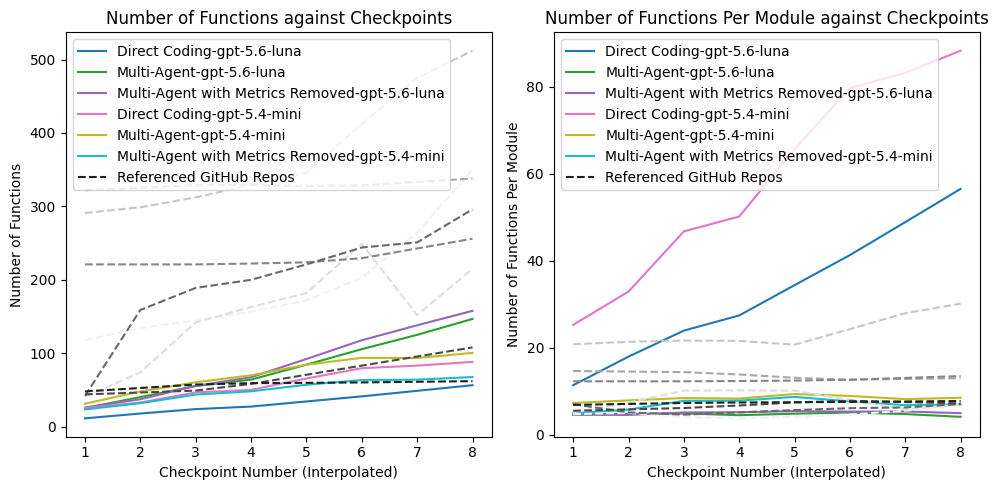

In [16]:
plot(scb_metrics_aggregated, ["number_of_functions", "number_of_functions_per_module"], with_references=True, y_labels=["Number of Functions", "Number of Functions Per Module"])

## N, Prop cost, impact size

noDesign, number_of_modules, gpt-5.6-luna: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
auto, number_of_modules, gpt-5.6-luna: [5.875, 8.339, 11.25, 15.018, 18.232, 21.393, 27.071, 35.125]
autoNoMetric, number_of_modules, gpt-5.6-luna: [6.0, 8.232, 11.089, 13.429, 17.482, 23.214, 27.125, 33.375]
noDesign, number_of_modules, gpt-5.4-mini: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
auto, number_of_modules, gpt-5.4-mini: [5.5, 6.732, 7.589, 8.143, 9.0, 10.071, 11.214, 11.875]
autoNoMetric, number_of_modules, gpt-5.4-mini: [5.25, 6.054, 6.411, 6.875, 7.125, 9.321, 11.0, 11.0]
references-average, number_of_modules: [13.5, 17.2, 20.39, 21.29, 22.04, 24.29, 24.52, 26.25]
noDesign, propagation_cost, gpt-5.6-luna: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
auto, propagation_cost, gpt-5.6-luna: [0.466, 0.401, 0.352, 0.311, 0.28, 0.25, 0.227, 0.198]
autoNoMetric, propagation_cost, gpt-5.6-luna: [0.468, 0.417, 0.368, 0.341, 0.309, 0.26, 0.238, 0.221]
noDesign, propagation_cost, gpt-5.4-mini: [1.0, 1.0, 1.

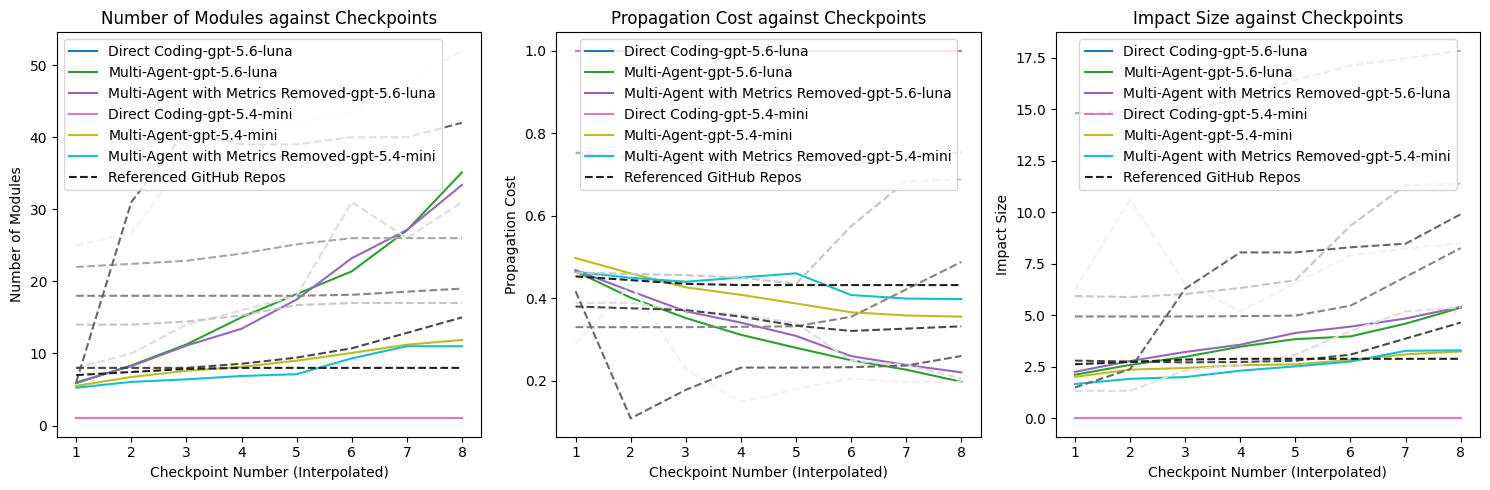

In [17]:
plot(scb_metrics_aggregated, ["number_of_modules", "propagation_cost", "impact_size"], with_references=True, y_labels=["Number of Modules", "Propagation Cost", "Impact Size"])

## Tests pass rate

noDesign, current, gpt-5.6-luna: [0.915, 0.865, 0.816, 0.878, 0.787, 0.794, 0.777, 0.808]
auto, current, gpt-5.6-luna: [0.712, 0.667, 0.597, 0.638, 0.512, 0.615, 0.507, 0.572]
autoNoMetric, current, gpt-5.6-luna: [0.687, 0.675, 0.586, 0.621, 0.528, 0.537, 0.593, 0.629]
noDesign, current, gpt-5.4-mini: [0.853, 0.665, 0.74, 0.563, 0.587, 0.561, 0.514, 0.417]
auto, current, gpt-5.4-mini: [0.726, 0.507, 0.513, 0.491, 0.32, 0.338, 0.229, 0.231]
autoNoMetric, current, gpt-5.4-mini: [0.409, 0.396, 0.31, 0.337, 0.258, 0.097, 0.139, 0.124]
noDesign, prev, gpt-5.6-luna: [1.0, 0.933, 0.882, 0.8, 0.808, 0.789, 0.783, 0.771]
auto, prev, gpt-5.6-luna: [1.0, 0.714, 0.655, 0.604, 0.615, 0.596, 0.519, 0.584]
autoNoMetric, prev, gpt-5.6-luna: [1.0, 0.701, 0.66, 0.63, 0.617, 0.521, 0.581, 0.588]
noDesign, prev, gpt-5.4-mini: [1.0, 0.823, 0.746, 0.65, 0.635, 0.6, 0.54, 0.491]
auto, prev, gpt-5.4-mini: [1.0, 0.654, 0.599, 0.545, 0.485, 0.384, 0.263, 0.268]
autoNoMetric, prev, gpt-5.4-mini: [1.0, 0.621, 0.4

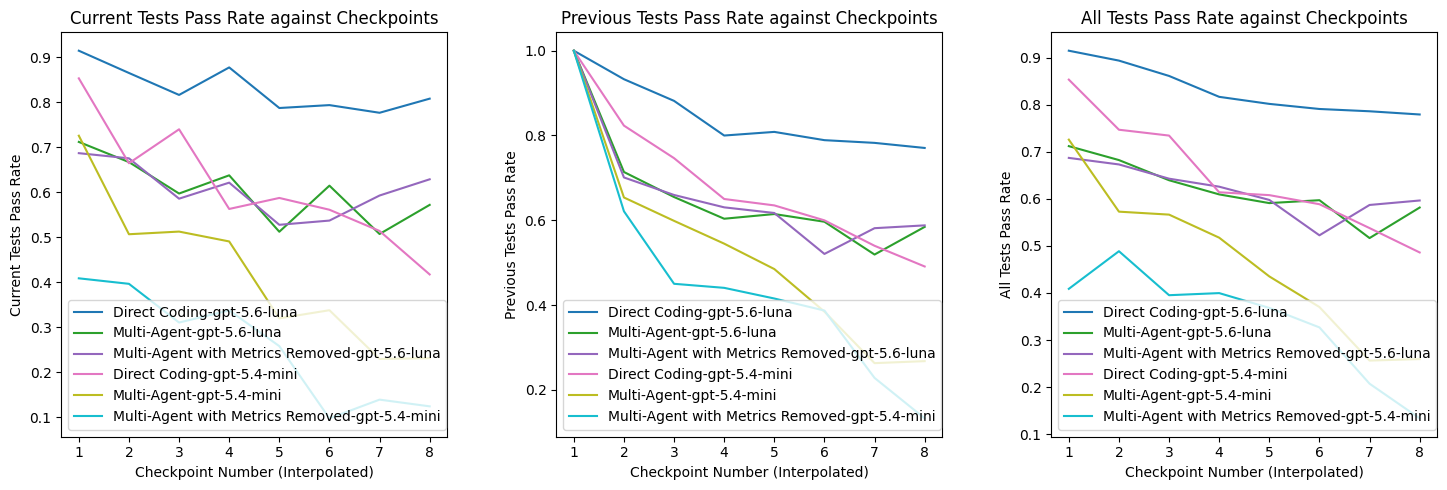

In [18]:
plot(test_metrics_aggregated, ["current", "prev", "all"], y_labels=["Current Tests Pass Rate", "Previous Tests Pass Rate", "All Tests Pass Rate"])

In [19]:
# Obtain test pass rates for GPT 5.6 and 5.4 respectively 
# These data are verified to be correct 

target_problems = [
    "code_search", "circuit_eval", "etl_pipeline", "meshctl", "mocked_http", "recli", "sheeteval", "sith"
    ]

def get_pass_rate(problems, mode, model): 
    results = [] 
    key = f"implementations_{mode}_codex_{model}"
    for problem in problems: 
        for entry in scb_test_metrics[problem][key]: 
            results.append(entry) 

    return average(results) 

for mode in ["noDesign", "auto", "autoTest"]: 
    for model in ["gpt-5.6-luna", "gpt-5.4-mini"]: 
        print(f"{mode}, {model}: { {k: round(v, 2) for k, v in get_pass_rate(target_problems, mode, model).items()} }")

noDesign, gpt-5.6-luna: {'current': 0.82, 'prev': 0.85, 'all': 0.83}
noDesign, gpt-5.4-mini: {'current': 0.59, 'prev': 0.66, 'all': 0.63}
auto, gpt-5.6-luna: {'current': 0.57, 'prev': 0.64, 'all': 0.59}
auto, gpt-5.4-mini: {'current': 0.4, 'prev': 0.5, 'all': 0.44}
autoTest, gpt-5.6-luna: {'current': 0.65, 'prev': 0.71, 'all': 0.68}
autoTest, gpt-5.4-mini: {'current': 0.23, 'prev': 0.32, 'all': 0.25}
